In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

In [2]:
base_dir = Path(r"C:\Users\myles\OneDrive\Desktop\adhesive_1_0_data")  # contains data_1_0_phi*
folders = sorted(base_dir.glob("data_1_0_phi*"))



In [3]:
def find_table_start(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Time"):
                return i
    raise ValueError(f"No table header found in {path}")

def find_table_end(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Loop"):
                return i
    return None

In [4]:
columns = []
column_names = []

for folder in folders:
    # phi from folder name: data_0_0_phi0.55
    mphi = re.search(r"phi([0-9.]+)", folder.name)
    if not mphi:
        continue
    phi_str = mphi.group(1)

    run_files = sorted(folder.glob("run_*"))  # e.g. run_0.01.txt etc.
    print(folder.name, "->", len(run_files), "run files")

    for file in run_files:
        start = find_table_start(file)
        end = find_table_end(file)

        df = pd.read_csv(
            file,
            delim_whitespace=True,
            skiprows=start,
            nrows=(end - start) if end is not None else None,
            on_bad_lines="skip",
            engine="python"
        )

        col = df.iloc[:, 4]  # 5th column (stress_xy)
        
    

        # a from filename safely: run_0.006.txt -> 0.006
        a_str = file.stem.replace("run_", "")



        new_name = f"phi{phi_str}_a{a_str}_stress_xy"
        col = col.rename(new_name)

        columns.append(col)
        column_names.append(new_name)

new_df = pd.concat(columns, axis=1)
new_df.columns = column_names
new_df.insert(0, "Time", range(len(new_df)))

print("Final dataframe shape:", new_df.shape)


new_df.head()

data_1_0_phi0.49 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarnin

data_1_0_phi0.50 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarnin

data_1_0_phi0.53 -> 14 run files


...

C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarnin

data_1_0_phi0.57 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2596901894.py:18: FutureWarnin

Final dataframe shape: (6001, 99)


,Time,phi0.49_a0.006_stress_xy,phi0.49_a0.01_stress_xy,phi0.49_a0.02_stress_xy,phi0.49_a0.03_stress_xy,phi0.49_a0.06_stress_xy,phi0.49_a0.1_stress_xy,phi0.49_a0.2_stress_xy,phi0.49_a0.3_stress_xy,phi0.49_a0.6_stress_xy,...,phi0.57_a0.06_stress_xy,phi0.57_a0.1_stress_xy,phi0.57_a0.2_stress_xy,phi0.57_a0.3_stress_xy,phi0.57_a0.6_stress_xy,phi0.57_a1.0_stress_xy,phi0.57_a2.0_stress_xy,phi0.57_a3.0_stress_xy,phi0.57_a5.0_stress_xy,phi0.57_a6.0_stress_xy
0,0,-0.023660,-0.023660,-0.023660,-0.023660,-0.023660,-0.023660,-0.023660,-0.023660,-0.023660,...,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768,-0.045768
1,1,-0.003051,-0.003051,-0.003051,-0.003052,-0.003052,-0.003051,-0.003046,-0.003041,-0.003048,...,-0.007020,-0.007028,-0.007025,-0.007016,-0.007020,-0.007011,-0.007026,-0.007017,-0.007031,-0.007025
2,2,-0.002931,-0.002931,-0.002931,-0.002928,-0.002929,-0.002930,-0.002931,-0.002930,-0.002931,...,-0.006554,-0.006554,-0.006554,-0.006552,-0.006554,-0.006549,-0.006550,-0.006551,-0.006558,-0.006558
3,3,-0.002579,-0.002578,-0.002579,-0.002579,-0.002579,-0.002579,-0.002578,-0.002579,-0.002579,...,-0.006386,-0.006387,-0.006378,-0.006379,-0.006382,-0.006387,-0.006384,-0.006389,-0.006387,-0.006391
4,4,-0.002635,-0.002635,-0.002634,-0.002634,-0.002620,-0.002624,-0.002624,-0.002631,-0.002630,...,-0.006435,-0.006436,-0.006435,-0.006434,-0.006434,-0.006435,-0.006436,-0.006452,-0.006451,-0.006449


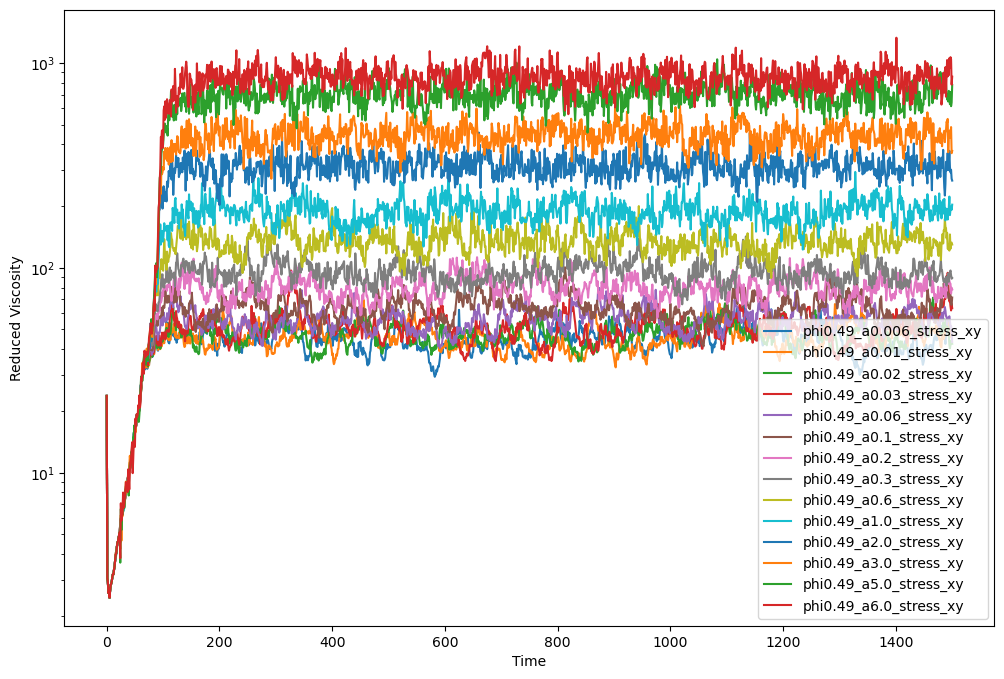

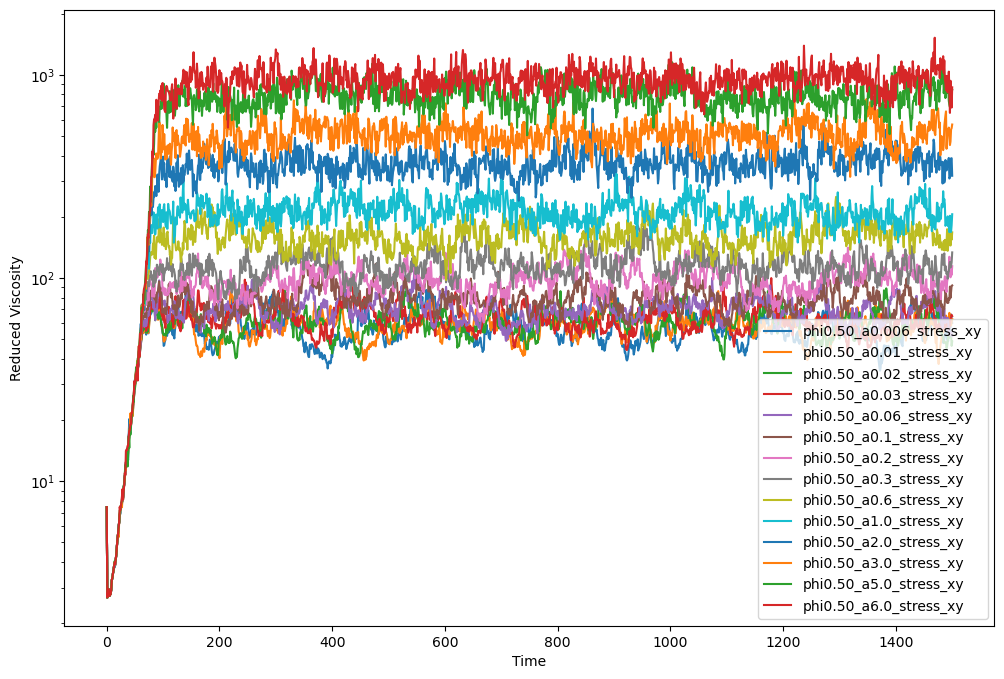

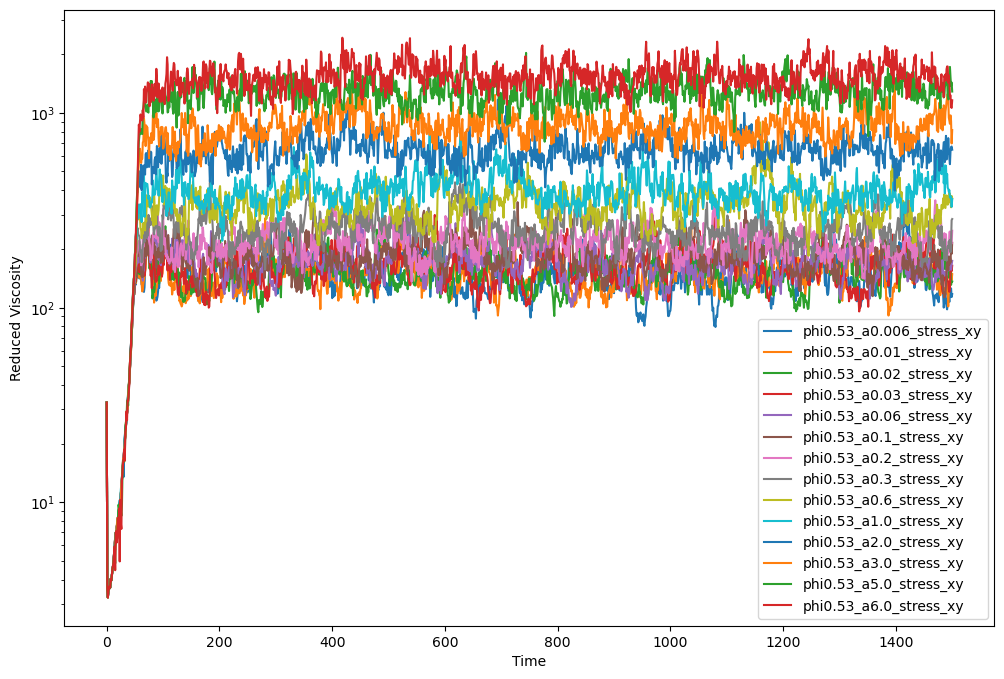

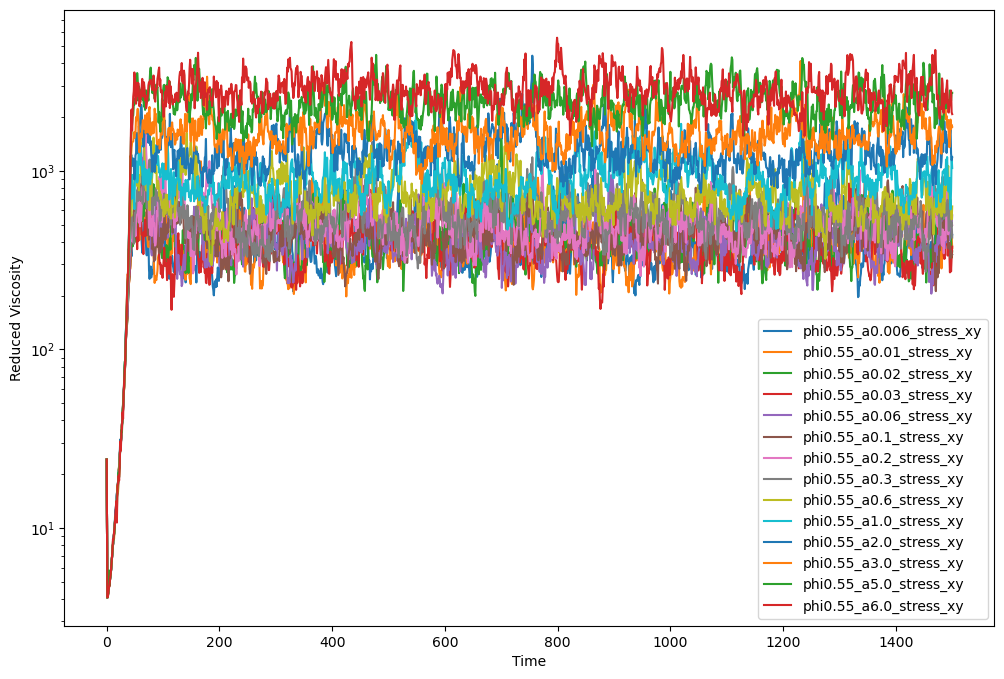

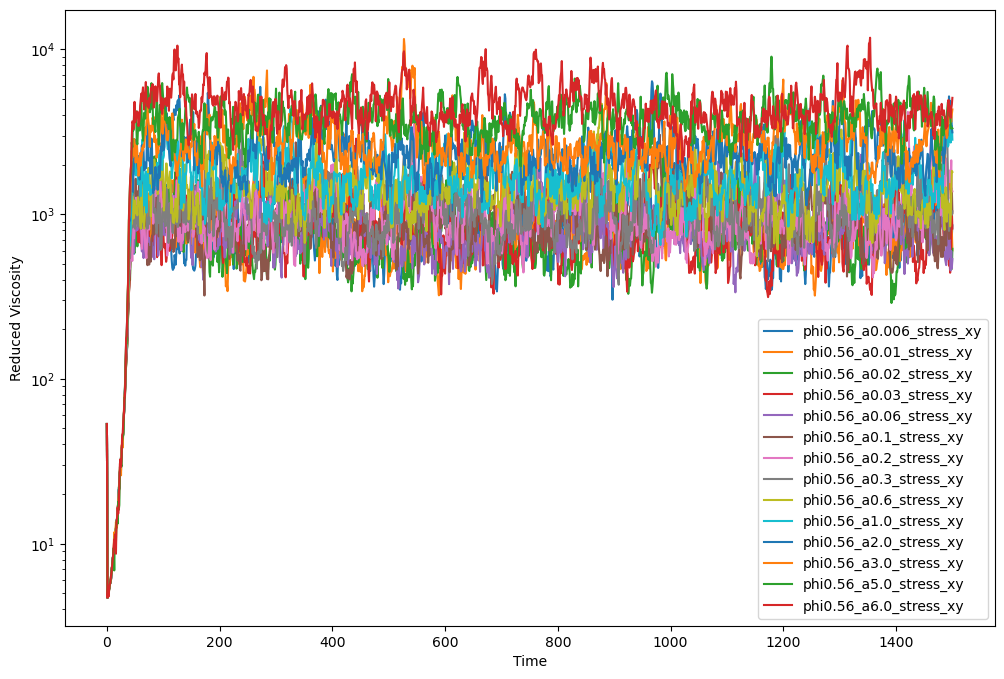

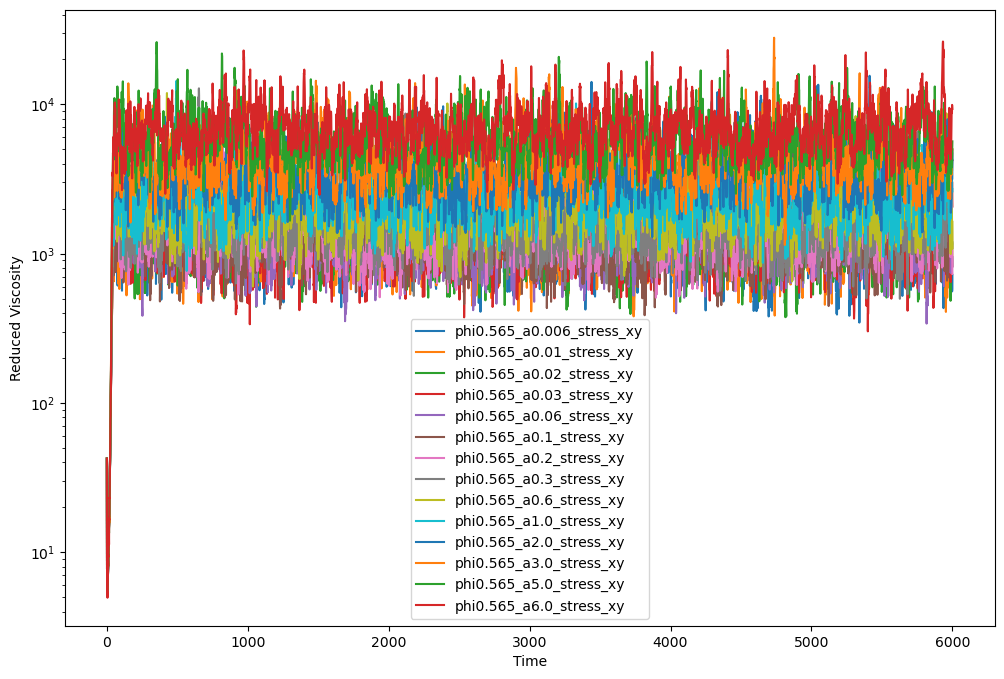

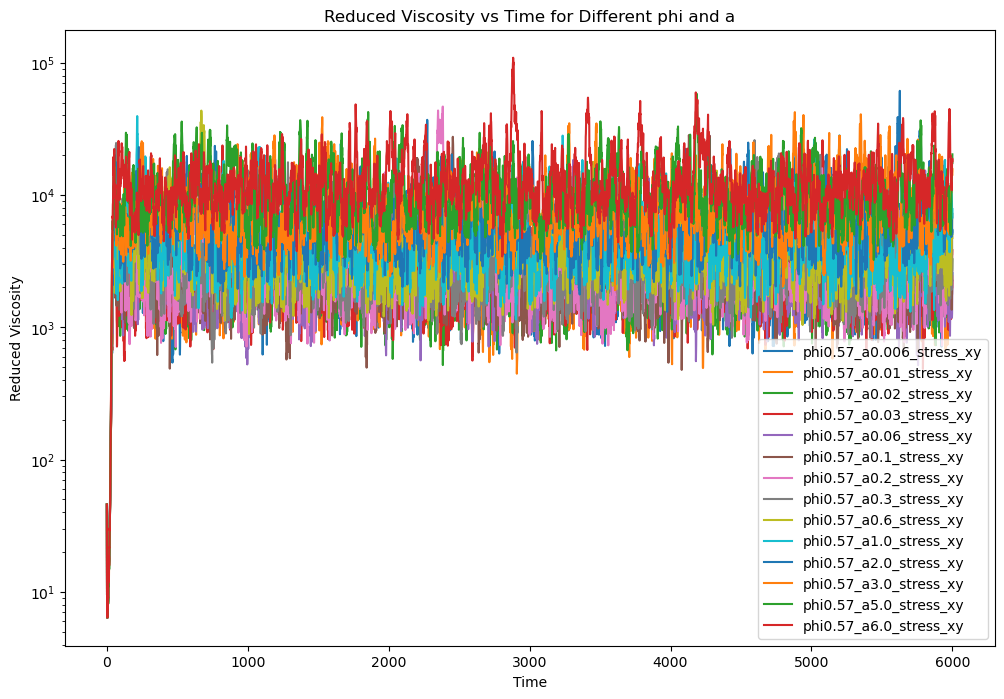

In [5]:

plt.figure(figsize=(12, 8))
for i, col in enumerate(new_df.columns[1:]):  # skip Time column
    if i % 14 == 0 and i > 0:
        plt.xlabel("Time")
        plt.ylabel("Reduced Viscosity")
        plt.yscale("log")
        plt.legend()
        plt.show()
        plt.figure(figsize=(12, 8))
    plt.plot(new_df["Time"], np.abs(new_df[col]/ (0.01*0.1)), label=col)
plt.xlabel("Time")
plt.ylabel("Reduced Viscosity")
plt.title("Reduced Viscosity vs Time for Different phi and a")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
eta_f = 0.1      # fluid viscosity
gamma_dot = 0.01 # shear rate

# steady state stress is between time 100 and the end
steady_state_stresses = []
for col in new_df.columns[1:]:  # skip Time column
    steady_state_stress = np.abs(new_df[col][100:].mean())  # average stress from time 100 to end
    steady_state_stresses.append(steady_state_stress)

print("Steady state stresses:", steady_state_stresses)

# reduced viscosity = (steady state stress) / (eta_f * gamma_dot)
reduced_viscosities = [stress / (eta_f * gamma_dot) for stress in steady_state_stresses]
print("Reduced viscosities:", reduced_viscosities)


Steady state stresses: [0.04498372813347609, 0.04635145099785867, 0.04781801925410421, 0.0512756642248394, 0.056227007165596005, 0.06429005573233404, 0.08036819312847966, 0.09560169275660242, 0.13489739920628122, 0.18864901106352605, 0.3134170339757316, 0.443019831270521, 0.7037856174732333, 0.8520032759314775, 0.05695206537901499, 0.05855197116416845, 0.060755548039971456, 0.06308148640328337, 0.07069430693433262, 0.0794882304375446, 0.09817199539685938, 0.1155385286531049, 0.1600491004803712, 0.21436789027837258, 0.3664585716488223, 0.5100769792148465, 0.7940118569593148, 0.9532909808065666, 0.15118823725624553, 0.15450353932119915, 0.15106846515774447, 0.16367733674161314, 0.1716744900214133, 0.18734371037116349, 0.21748573078515343, 0.25683723068522485, 0.34257253902212703, 0.4050269664739472, 0.6508271956388294, 0.8658671647822984, 1.3001950532048536, 1.5572366035760172, 0.43181263627408994, 0.42155700655246253, 0.4398086128551035, 0.3969612706923626, 0.42815360737330477, 0.461368

In [7]:
# Creating a clear dataframe with columns: phi, a, reduced_viscosity
data = []
for col, eta_r in zip(new_df.columns[1:], reduced_viscosities):
    m = re.match(r"phi([0-9.]+)_a([0-9.]+)_stress_xy", col)
    if m:
        phi = float(m.group(1))
        a = float(m.group(2))
        data.append({"phi": phi, "a": a, "reduced_viscosity": eta_r})
df_viscosity = pd.DataFrame(data)
print(df_viscosity)

     phi      a  reduced_viscosity
0   0.49  0.006          44.983728
1   0.49  0.010          46.351451
2   0.49  0.020          47.818019
3   0.49  0.030          51.275664
4   0.49  0.060          56.227007
..   ...    ...                ...
93  0.57  1.000        5357.830427
94  0.57  2.000        6920.266700
95  0.57  3.000        8635.147898
96  0.57  5.000       11154.408561
97  0.57  6.000       13331.800285

[98 rows x 3 columns]


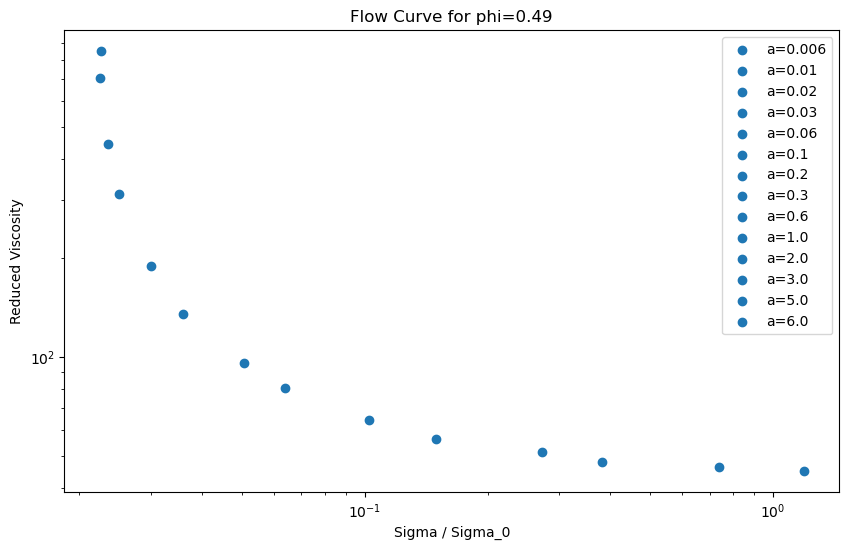

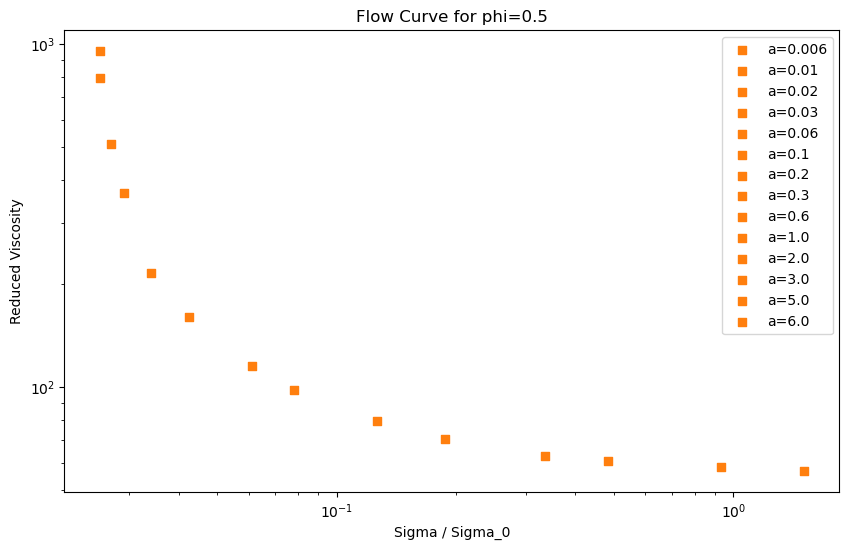

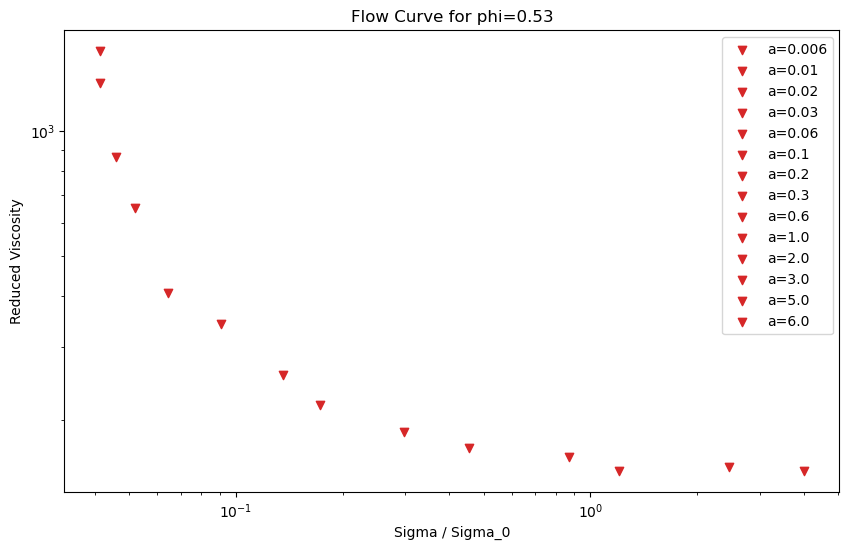

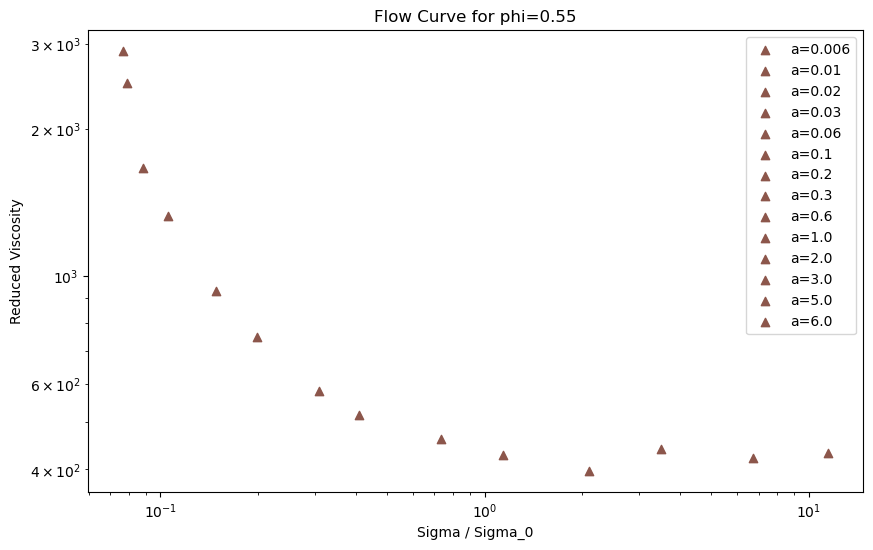

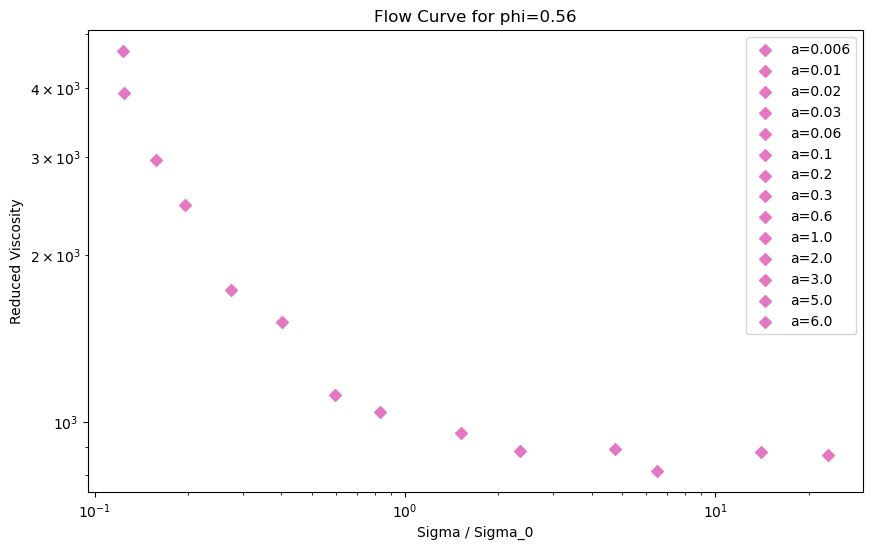

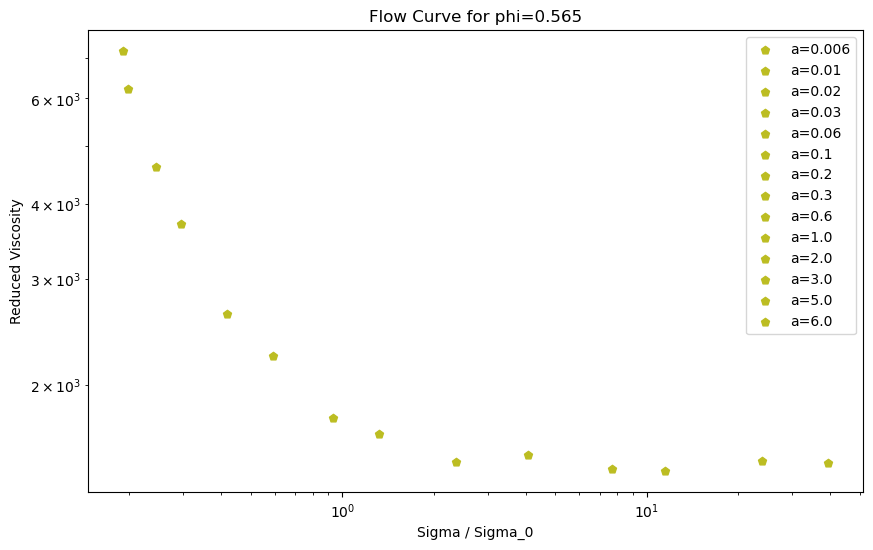

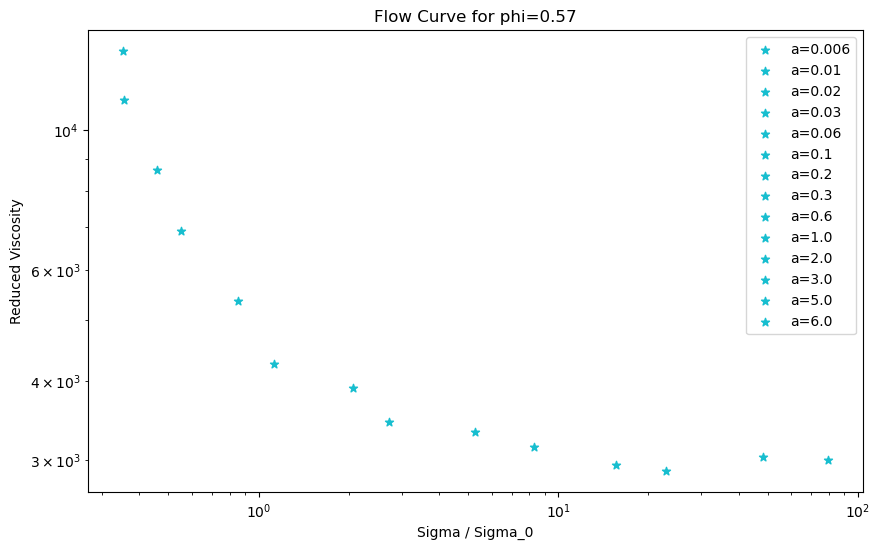

In [8]:
# build style for each phi
phis = sorted({float(re.search(r"phi([0-9.]+)", c).group(1))
               for c in new_df.columns[1:]})
markers = ['o','s','v','^','D','p','*','h','x','+']        # as many as needed
colors  = plt.cm.tab10(np.linspace(0, 1, len(phis)))      # or any colormap

phi_styles = {phi: {'marker': markers[i % len(markers)],
                    'color': colors[i]}
              for i, phi in enumerate(phis)}

# make one figure per packing fraction
for phi in phis:
    plt.figure(figsize=(10, 6))
    for idx, col in enumerate(new_df.columns[1:]):           # skip Time
        m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
        if not m:
            continue
        if float(m.group(1)) != phi:                        # only this phi
            continue
        a = float(m.group(2))

        sigma   = steady_state_stresses[idx]
        sigma_0 = 2 * np.pi * a

        style = phi_styles[phi]
        plt.scatter(sigma / sigma_0,
                    reduced_viscosities[idx],
                    color=style['color'],
                    marker=style['marker'],
                    label=f"a={a}")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Sigma / Sigma_0")
    plt.ylabel("Reduced Viscosity")
    plt.title(f"Flow Curve for phi={phi}")
    plt.legend()
    plt.show()
plt.show()

In [9]:
# ============================================================
# UNCERTAINTY METHOD 1: Fixed correlation time = 1 strain unit
# ============================================================
# tau_corr = 1 strain unit = 1/gamma_dot timesteps = 100 timesteps
# N_eff = N / (2 * tau_steps + 1)
# SEM_corrected = std / sqrt(N_eff)

tau_steps = 1.0 / gamma_dot          # = 100 timesteps

sem_strain = []
for col in new_df.columns[1:]:       # skip Time
    series = new_df[col][200:].dropna()
    N      = len(series)
    n_eff  = max(N / (2 * tau_steps + 1), 1.0)
    std    = series.std(ddof=1)
    sem_strain.append((std / np.sqrt(n_eff)) / (eta_f * gamma_dot))

sem_strain = np.array(sem_strain)
print("SEM (strain-corrected):", sem_strain)
print(f"Correction factor vs naive: {(sem_strain / np.array([new_df[col][200:].sem() / (eta_f * gamma_dot) for col in new_df.columns[1:]])).mean():.1f}x on average")

SEM (strain-corrected): [   2.24531906    2.52214885    2.28378651    3.14223736    2.6863818
    3.3858444     3.88439174    4.65090991    6.90352302    9.74826695
   15.31956025   22.30390809   35.6349881    42.74220176    3.60056667
    3.07366314    3.50405672    3.54233955    3.65722651    4.42948794
    5.55975174    6.72702234    8.87515513   11.68587292   20.17469088
   28.5938574    44.35730943   48.1818781    12.65680974   12.25421465
   11.10170246   13.25011295   12.94165952   14.2829959    13.50367928
   18.56636456   28.50969417   28.37020817   40.88127173   55.17600895
   74.50660161   93.85289824   56.75410749   47.97656609   52.96032797
   42.47263034   47.68731817   46.70785514   48.38678698   59.35767583
   73.99669391   97.37192019  131.09205126  145.7729454   196.13137065
  240.6150337   137.77340341  156.88612819  131.26081155  138.88007343
  143.91857152  137.55407712  171.15842814  181.6875311   206.61281752
  220.63898659  278.54334053  425.64048449  368.223763

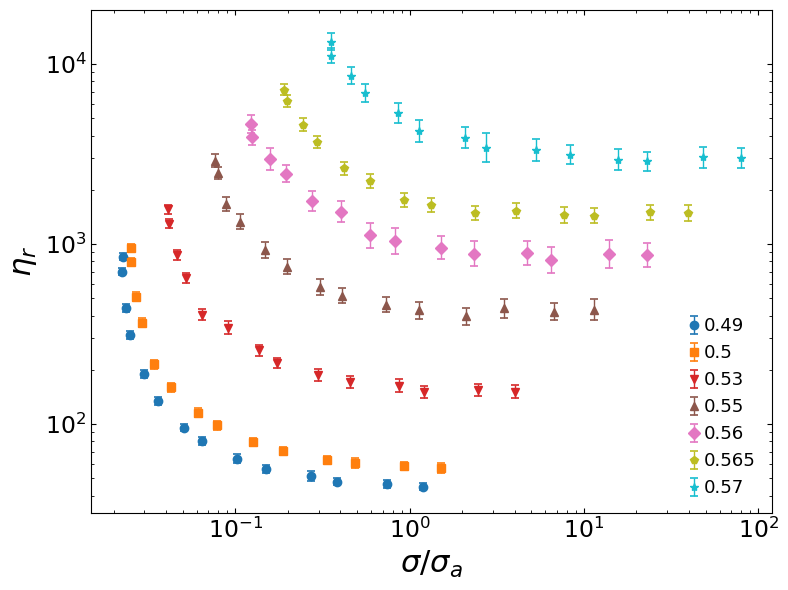

In [10]:
# ============================================================
# FLOW CURVE — fixed tau = 1 strain unit uncertainty
# ============================================================

def log_errorbars(means, sems):
    """Asymmetric log-space error bars so caps are visible on log axes."""
    means = np.asarray(means, dtype=float)
    sems  = np.asarray(sems,  dtype=float)
    rel   = sems / means
    return means * (1 - np.exp(-rel)), means * (np.exp(rel) - 1)

fig, ax = plt.subplots(figsize=(8, 6))
plotted_phis = set()

for idx, col in enumerate(new_df.columns[1:]):
    m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
    if not m:
        continue
    phi = float(m.group(1))
    a   = float(m.group(2))

    sigma   = steady_state_stresses[idx]
    sigma_0 = 2 * np.pi * a
    eta_r   = reduced_viscosities[idx]

    lo, hi = log_errorbars([eta_r], [sem_strain[idx]])

    style = phi_styles[phi]
    label = f"{phi}" if phi not in plotted_phis else None

    ax.errorbar(sigma / sigma_0, eta_r,
                yerr=[[lo[0]], [hi[0]]],
                fmt=style['marker'],
                color=style['color'],
                capsize=3, capthick=1.2, elinewidth=1.0,
                label=label)

    plotted_phis.add(phi)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\sigma / \sigma_a$", fontsize=22, fontweight='bold')
ax.set_ylabel(r"$\eta_r$", fontsize=22, fontweight='bold')
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.tick_params(labelsize=17)
ax.legend(fontsize=13, frameon=False, handlelength=0.5, handletextpad=0.3)
plt.tight_layout()
plt.savefig("flowcurve_strain_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\myles\AppData\Local\Temp\ipykernel_77364\3799349425.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


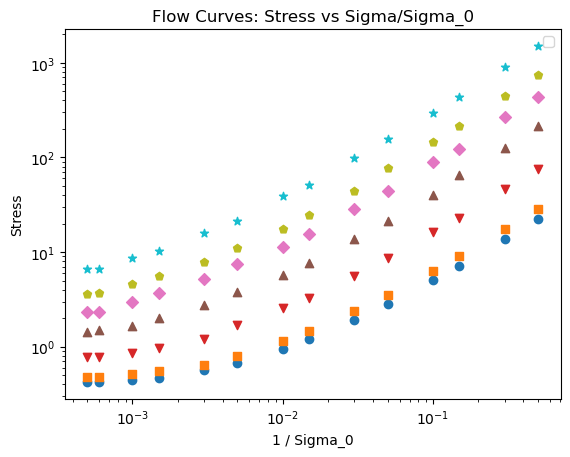

In [11]:
from scipy.optimize import curve_fit

for idx, col in enumerate(new_df.columns[1:]):           # skip Time
    m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
    if not m:
        continue
    phi = float(m.group(1))
    a   = float(m.group(2))

    sigma   = steady_state_stresses[idx]
    sigma_0 = 2 * np.pi * a

    style = phi_styles[phi]
    label = f"phi={phi}" if phi not in plotted_phis else None


    plt.scatter((3*0.1*0.01)/a,
                sigma*(3/a),
                color=style['color'],
                marker=style['marker'],
                label=label)

    plotted_phis.add(phi)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("1 / Sigma_0")
plt.ylabel("Stress")
plt.title("Flow Curves: Stress vs Sigma/Sigma_0")
plt.legend()
plt.show()

In [12]:
# --- 1) collect points per phi ---
from collections import defaultdict


points_by_phi = defaultdict(list)

for idx, col in enumerate(new_df.columns[1:]):  # skip Time
    m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
    if not m:
        continue

    phi = float(m.group(1))
    a   = float(m.group(2))

    sigma   = steady_state_stresses[idx] *(3/a)  # your y value (stress)
    sigma_0 = 2 * np.pi * a                # your stress scale
    x = (3*0.1*0.01)/a            # x = (1/sigma0)^(1/2)

    points_by_phi[phi].append((x, sigma))

# --- 2) fit first 3 smallest-x points for each phi, print intercept ---
sigma_y_by_phi = {}

for phi, pts in sorted(points_by_phi.items()):
    pts_sorted = sorted(pts, key=lambda t: t[0])   # sort by x (ascending)
    if len(pts_sorted) < 3:
        print(f"phi={phi}: only {len(pts_sorted)} points -> skipping")
        continue

    xs = np.array([p[0] for p in pts_sorted[:3]])
    ys = np.array([p[1] for p in pts_sorted[:3]])

    # linear fit: y = m x + b
    m_fit, b_fit = np.polyfit(xs, ys, 1)
    sigma_y_by_phi[phi] = b_fit

    print(f"phi={phi}: fit on smallest 3 x -> sigma_y (y-intercept) = {b_fit:.6g}, slope = {m_fit:.6g}")

phi=0.49: fit on smallest 3 x -> sigma_y (y-intercept) = 0.403039, slope = 39.132
phi=0.5: fit on smallest 3 x -> sigma_y (y-intercept) = 0.437443, slope = 71.8092
phi=0.53: fit on smallest 3 x -> sigma_y (y-intercept) = 0.678077, slope = 185.891
phi=0.55: fit on smallest 3 x -> sigma_y (y-intercept) = 1.23413, slope = 428.252
phi=0.56: fit on smallest 3 x -> sigma_y (y-intercept) = 1.60175, slope = 1353.85
phi=0.565: fit on smallest 3 x -> sigma_y (y-intercept) = 2.5336, slope = 2072.58
phi=0.57: fit on smallest 3 x -> sigma_y (y-intercept) = 4.39073, slope = 4200.71


phi=0.49: sigma_y (y-intercept) = 0.403039
phi=0.5: sigma_y (y-intercept) = 0.437443
phi=0.53: sigma_y (y-intercept) = 0.678077
phi=0.55: sigma_y (y-intercept) = 1.23413
phi=0.56: sigma_y (y-intercept) = 1.60175
phi=0.565: sigma_y (y-intercept) = 2.5336
phi=0.57: sigma_y (y-intercept) = 4.39073


<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2436126659.py:66: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat{\dot\gamma}$", fontsize=16, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\2436126659.py:67: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat{\sigma}$", fontsize=16, fontweight='bold')


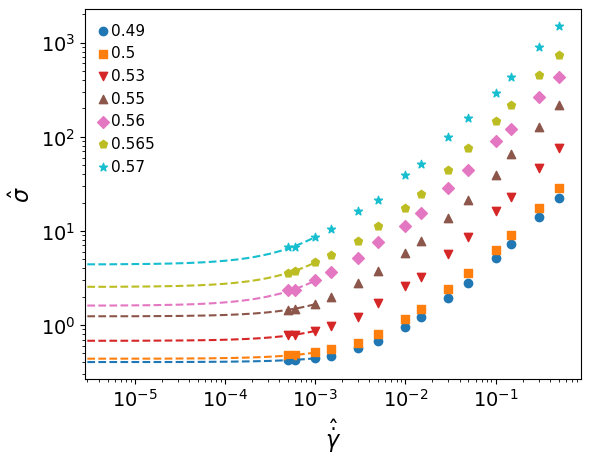

In [13]:
points_by_phi = defaultdict(list)
plotted_phis = set() 
# --- First pass: collect data (no fitting yet) ---
for idx, col in enumerate(new_df.columns[1:]):  # skip Time
    m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
    if not m:
        continue

    phi = float(m.group(1))
    a   = float(m.group(2))

    sigma   = steady_state_stresses[idx] *(3/a)
    sigma_0 = 2 * np.pi * a
    x = (3*0.1*0.01)/a

    points_by_phi[phi].append((x, sigma))

# --- Second pass: plot + fit ---
for phi, pts in sorted(points_by_phi.items()):

    style = phi_styles[phi]
    label = f"{phi}" if phi not in plotted_phis else None

    # sort by smallest x
    pts_sorted = sorted(pts, key=lambda t: t[0])

    xs = np.array([p[0] for p in pts_sorted])
    ys = np.array([p[1] for p in pts_sorted])

    # scatter all points
    plt.scatter(xs,
                ys,
                color=style['color'],
                marker=style['marker'],
                label=label)

    plotted_phis.add(phi)

    # --- Fit first 3 smallest x points ---
    if len(xs) >= 3:
        xs_fit = xs[:3]
        ys_fit = ys[:3]

        # linear model
        def model(x, m, b):
            return m * x + b

        popt, _ = curve_fit(model, xs_fit, ys_fit)

        m_fit, b_fit = popt

        print(f"phi={phi}: sigma_y (y-intercept) = {b_fit:.6g}")

        # plot fitted line over full x-range
        x_line = np.linspace(0, xs_fit[-1], 200)
        y_line = model(x_line, m_fit, b_fit)

        plt.plot(x_line,
                 y_line,
                 color=style['color'],
                 linestyle='--'
                 )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("$\hat{\dot\gamma}$", fontsize=16, fontweight='bold')
plt.ylabel("$\hat{\sigma}$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=11, frameon=False, handlelength=0.5, handletextpad=0.3)
plt.savefig("yield_stress_determine.png", dpi= 1200, bbox_inches="tight")
plt.show()

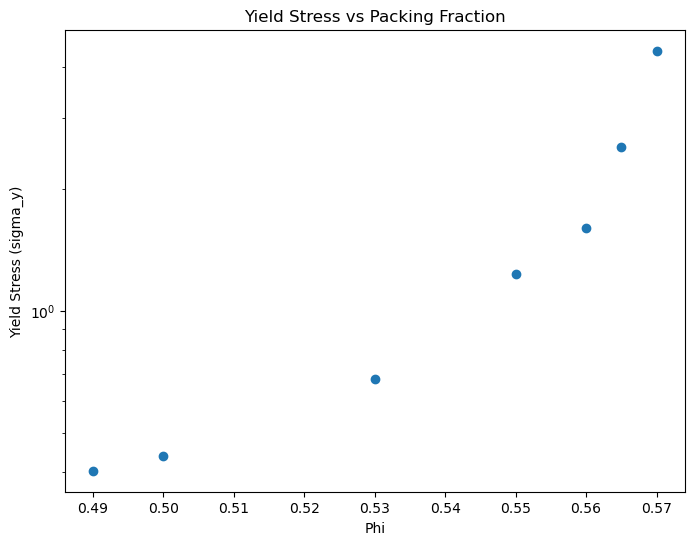

In [14]:
# Plot the yield stress (sigma_y) vs phi using the fitted intercepts
plt.figure(figsize=(8, 6))
phis = sorted(sigma_y_by_phi.keys())
sigma_ys = [sigma_y_by_phi[phi] for phi in phis]
plt.plot(phis, sigma_ys, marker='o', linestyle='')
plt.xlabel("Phi")
plt.yscale("log")
plt.ylabel("Yield Stress (sigma_y)")
plt.title("Yield Stress vs Packing Fraction")
plt.show()

df_export = pd.DataFrame({
    "phi" : phis,
    "sigma_y" : sigma_ys
})

df_export.to_csv("1_0_flowcurve.csv", index=False)

In [15]:
columns_1 = []
column_1_names = []

for folder in folders:
    # phi from folder name: data_1_0_phi0.55
    mphi = re.search(r"phi([0-9.]+)", folder.name)
    if not mphi:
        continue
    phi_str = mphi.group(1)

    run_files = sorted(folder.glob("run_*"))  # e.g. run_0.01.txt etc.
    print(folder.name, "->", len(run_files), "run files")

    for file in run_files:
        start = find_table_start(file)
        end = find_table_end(file)

        df2 = pd.read_csv(
            file,
            delim_whitespace=True,
            skiprows=start,
            nrows=(end - start) if end is not None else None,
            on_bad_lines="skip",
            engine="python"
        )

        col = df2.iloc[:, 7]  # 8th column (contact_number)
        
    

        # a from filename safely: run_0.006.txt -> 0.006
        a_str = file.stem.replace("run_", "")



        new_name = f"phi{phi_str}_a{a_str}_contact_number"
        col = col.rename(new_name)

        columns_1.append(col)
        column_1_names.append(new_name)

new_df2 = pd.concat(columns_1, axis=1)
new_df2.columns = column_1_names
new_df2.insert(0, "Time", range(len(new_df2)))

print("Final dataframe shape:", new_df2.shape)


print(new_df2)

data_1_0_phi0.49 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWa

data_1_0_phi0.50 -> 14 run files
data_1_0_phi0.53 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWa

data_1_0_phi0.55 -> 14 run files
data_1_0_phi0.56 -> 14 run files


...

C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWa

data_1_0_phi0.57 -> 14 run files


C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWa

Final dataframe shape: (6001, 99)
      Time  phi0.49_a0.006_contact_number  phi0.49_a0.01_contact_number  \
0        0                          0.000                         0.000   
1        1                          0.008                         0.008   
2        2                          0.014                         0.014   
3        3                          0.014                         0.014   
4        4                          0.018                         0.018   
...    ...                            ...                           ...   
5996  5996                            NaN                           NaN   
5997  5997                            NaN                           NaN   
5998  5998                            NaN                           NaN   
5999  5999                            NaN                           NaN   
6000  6000                            NaN                           NaN   

      phi0.49_a0.02_contact_number  phi0.49_a0.03_contact_number 

C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\1288715030.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(


In [16]:
steady = new_df2[(new_df2["Time"] >= 100) & (new_df2["Time"] <= 500)]

# mean for every column except Time
steady_means = steady.drop(columns=["Time"]).mean()

print(steady_means)




phi0.49_a0.006_contact_number    2.305945
phi0.49_a0.01_contact_number     2.377870
phi0.49_a0.02_contact_number     2.540374
phi0.49_a0.03_contact_number     2.708279
phi0.49_a0.06_contact_number     3.057461
                                   ...   
phi0.57_a1.0_contact_number      3.896998
phi0.57_a2.0_contact_number      4.053506
phi0.57_a3.0_contact_number      4.157107
phi0.57_a5.0_contact_number      4.279840
phi0.57_a6.0_contact_number      4.318768
Length: 98, dtype: float64


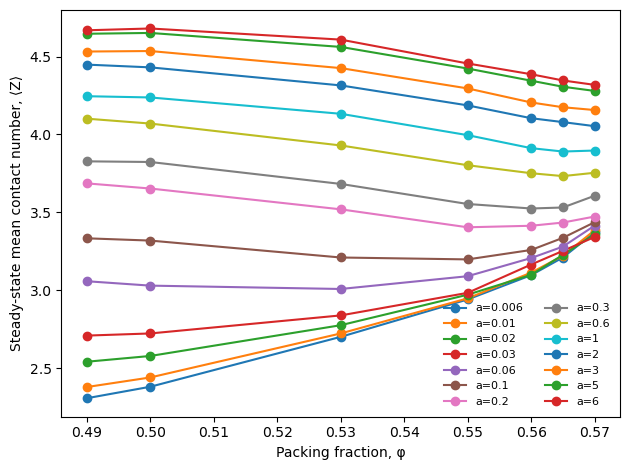

In [17]:
records = []
for name, zbar in steady_means.items():
    m = re.search(r"phi([0-9.]+)_a([0-9.eE+-]+)_contact_number", name)
    if not m:
        continue
    phi = float(m.group(1))
    a   = float(m.group(2))
    records.append({"phi": phi, "a": a, "Z_mean": zbar})

tidy = pd.DataFrame(records)

# optional: sort so lines draw nicely
tidy = tidy.sort_values(["a", "phi"])

# ---- Plot: Z_mean vs phi, one line per a ----
plt.figure()
for a, g in tidy.groupby("a"):
    plt.plot(g["phi"], g["Z_mean"], marker="o", label=f"a={a:g}")

plt.xlabel("Packing fraction, φ")
plt.ylabel("Steady-state mean contact number, ⟨Z⟩")

# With 14 lines, legend can get big:
plt.legend(ncol=2, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

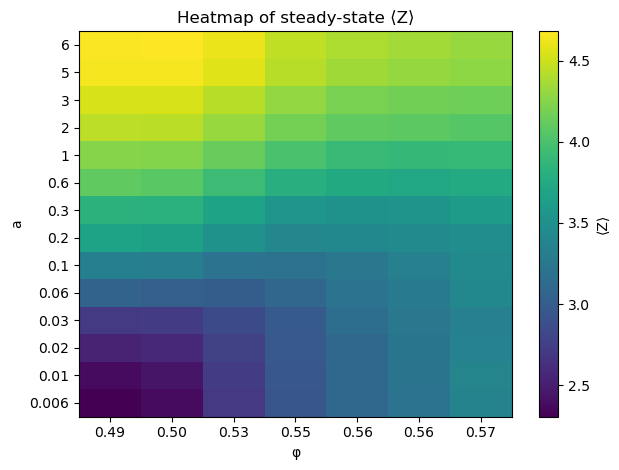

In [18]:
pivot = tidy.pivot_table(index="a", columns="phi", values="Z_mean", aggfunc="mean")
pivot = pivot.sort_index().sort_index(axis=1)

plt.figure()
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(len(pivot.columns)), [f"{c:.2f}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{r:g}" for r in pivot.index])
plt.xlabel("φ")
plt.ylabel("a")
plt.title("Heatmap of steady-state ⟨Z⟩")
plt.colorbar(label="⟨Z⟩")
plt.tight_layout()
plt.show()

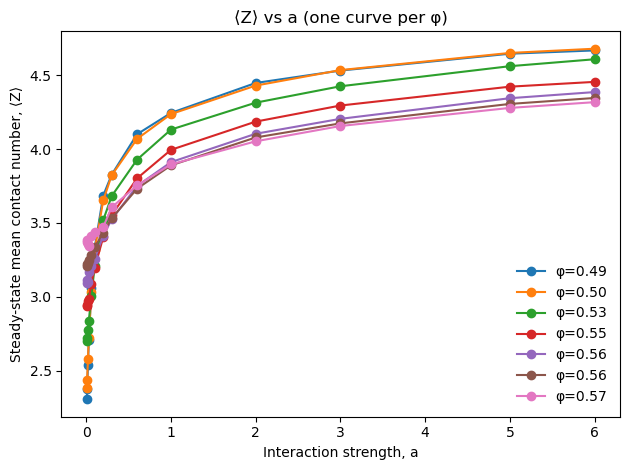

In [19]:
plt.figure()
for phi, g in tidy.groupby("phi"):
    g = g.sort_values("a")
    plt.plot(g["a"], g["Z_mean"], marker="o", label=f"φ={phi:.2f}")

plt.xlabel("Interaction strength, a")
plt.ylabel("Steady-state mean contact number, ⟨Z⟩")
plt.title("⟨Z⟩ vs a (one curve per φ)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
C:\Users\myles\AppData\Local\Temp\ipykernel_77364\995125557.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma / \sigma_0$", fontsize=14, fontweight='bold')


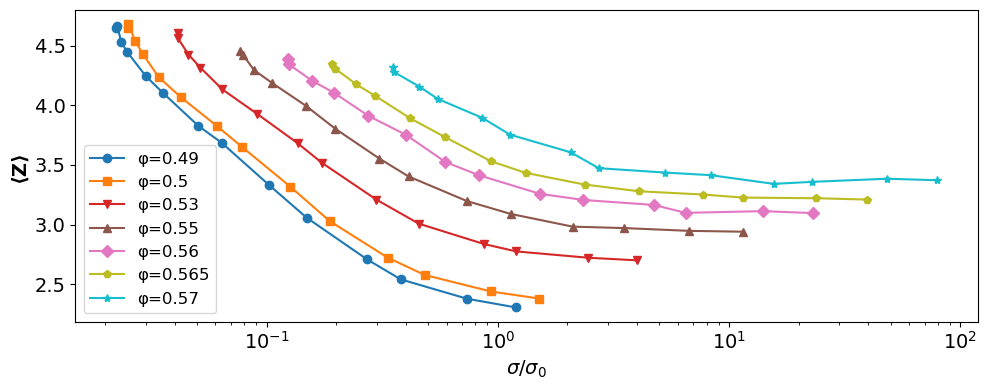

In [20]:
import pickle
plt.figure(figsize=(10, 4))

for phi in phis:
    style = phi_styles[phi]

    xs = []
    zs = []
    for idx, col in enumerate(new_df.columns[1:]):   # skip Time
        m = re.search(r"phi([0-9.]+)_a([0-9.]+)", col)
        if not m:
            continue
        if float(m.group(1)) != phi:                # only this φ
            continue
        a = float(m.group(2))

        sigma   = steady_state_stresses[idx]
        sigma_0 = 2 * np.pi * a

        z_mean = tidy[(tidy["phi"] == phi) & (tidy["a"] == a)]["Z_mean"].values[0]
        xs.append(sigma / sigma_0)
        zs.append(z_mean)

    # sort by x so the connecting line is monotonic
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    zs = np.array(zs)[order]

    plt.plot(xs, zs,
             marker=style['marker'],
             color=style['color'],
             linestyle='-',
             label=f"φ={phi}")

plt.xscale("log")
plt.xlabel("$\sigma / \sigma_0$", fontsize=14, fontweight='bold')
plt.ylabel("⟨Z⟩", fontsize=14, fontweight='bold')
plt.yticks(size=14)
plt.xticks(size=14)
plt.legend(fontsize=12)
plt.tight_layout()
fig = plt.gcf()  # grab the current figure
with open('fig2.pkl', 'wb') as f:  # change to fig2.pkl, fig3.pkl
    pickle.dump(fig, f)
plt.show()